# M\*A\*S\*H — IMDb Episode Analytics

| Cell | Purpose |
|------|--------|
| 1 | Install dependencies |
| 2 | Imports |
| 3 | Fetch & cache from 5 IMDb datasets (takes some time) |
| 4 | Data cleaning & feature engineering |
| 5 | Special episode classification + cast-director tagging |
| 6 | Chart 1: Ratings timeline with toggleable overlays |
| 7 | Chart 2: Season box plots |
| 8 | Chart 3: Top 15 & Bottom 10 |
| 9 | Chart 4: Rating heatmap |
| 10 | Chart 5: Audience engagement |
| 11 | Chart 6: Season averages |
| 12 | Chart 7: Director leaderboard (gold = cast, blue = pro) |
| 13 | Chart 8: Special episodes vs regular |
| 14 | Chart 9: Cast-directed episode analysis |
| 15 | Export standalone HTML report |

In [1]:
# M*A*S*H — IMDb Episode Analytics  v2
# Run cells top to bottom. Cell 3 downloads ~400 MB on first run; cached after.
import subprocess
r = subprocess.run(
    ['pip', 'install', 'plotly', 'pandas', 'tqdm', 'requests', '-q'],
    capture_output=True, text=True
)
print("\u2713 Dependencies ready" if r.returncode == 0 else r.stderr[:400])


✓ Dependencies ready


In [2]:
from plotly.io import to_html
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import pandas as pd, requests, gzip, io, os, time, warnings
from tqdm.notebook import tqdm
warnings.filterwarnings('ignore')
pd.set_option('display.max_colwidth', 60)

PALETTE = px.colors.qualitative.Set2 + px.colors.qualitative.Pastel1
print("\u2713 Imports OK")


✓ Imports OK


## 📡 Fetch & Cache
Pulls 5 IMDb official datasets. The `directors` column is now fully populated.

In [3]:
# ── Fetch & Cache (5 IMDb datasets: episodes, ratings, titles, crew, names) ───
# First run: ~400 MB total, ~5-10 min. Subsequent runs: instant from cache.

CACHE_FILE = 'mash_episodes.csv'
MASH_ID    = 'tt0068098'
IMDB_BASE  = 'https://datasets.imdbws.com/'

def fetch_mash_data():

    # 1 ── Episode index (~25 MB) ─────────────────────────────────────────────
    print("\U0001f4e5 1/5  Episode index (~25 MB)...")
    r = requests.get(IMDB_BASE + 'title.episode.tsv.gz')
    with gzip.open(io.BytesIO(r.content)) as f:
        all_eps = pd.read_csv(f, sep='\t', na_values='\\N',
                              dtype={'seasonNumber':'Int64','episodeNumber':'Int64'})
    mash_eps    = all_eps[all_eps['parentTconst'] == MASH_ID].copy()
    episode_ids = set(mash_eps['tconst'])
    print(f"  \u2713  {len(mash_eps)} episodes")

    # 2 ── Ratings (~6 MB) ───────────────────────────────────────────────────
    print("\U0001f4e5 2/5  Ratings (~6 MB)...")
    r = requests.get(IMDB_BASE + 'title.ratings.tsv.gz')
    with gzip.open(io.BytesIO(r.content)) as f:
        ratings = pd.read_csv(f, sep='\t', na_values='\\N')
    df_base = mash_eps.merge(ratings, on='tconst', how='left')
    print("  \u2713  merged")

    # 3 ── Title basics (~100 MB) ─────────────────────────────────────────────
    print("\U0001f4e5 3/5  Title basics (~100 MB)...")
    r = requests.get(IMDB_BASE + 'title.basics.tsv.gz')
    with gzip.open(io.BytesIO(r.content)) as f:
        basics = pd.read_csv(f, sep='\t', na_values='\\N',
                             usecols=['tconst', 'primaryTitle', 'startYear'])
    bm        = basics[basics['tconst'].isin(episode_ids)]
    title_map = bm.set_index('tconst')['primaryTitle'].to_dict()
    year_map  = bm.set_index('tconst')['startYear'].to_dict()
    print(f"  \u2713  {len(title_map)} titles")

    # 4 ── Crew data (~50 MB) ─────────────────────────────────────────────────
    print("\U0001f4e5 4/5  Crew data (~50 MB)...")
    r = requests.get(IMDB_BASE + 'title.crew.tsv.gz')
    with gzip.open(io.BytesIO(r.content)) as f:
        crew = pd.read_csv(f, sep='\t', na_values='\\N',
                           usecols=['tconst', 'directors'])
    mash_crew   = crew[crew['tconst'].isin(episode_ids)].copy()
    all_nconsts = set()
    for d in mash_crew['directors'].dropna():
        all_nconsts.update(d.split(','))
    print(f"  \u2713  {len(all_nconsts)} director IDs collected")

    # 5 ── Name basics (~200 MB) ──────────────────────────────────────────────
    print("\U0001f4e5 5/5  Name lookup (~200 MB, largest file)...")
    r = requests.get(IMDB_BASE + 'name.basics.tsv.gz')
    with gzip.open(io.BytesIO(r.content)) as f:
        names = pd.read_csv(f, sep='\t', na_values='\\N',
                            usecols=['nconst', 'primaryName'])
    name_map = (names[names['nconst'].isin(all_nconsts)]
                .set_index('nconst')['primaryName'].to_dict())

    def resolve_directors(d_str):
        if pd.isna(d_str): return None
        return ', '.join(name_map.get(n, n) for n in d_str.split(','))

    dir_series           = mash_crew.set_index('tconst')['directors'].apply(resolve_directors)
    df_base['directors'] = df_base['tconst'].map(dir_series)
    print(f"  \u2713  directors resolved")

    # ── Assemble ──────────────────────────────────────────────────────────────
    df_base['title']    = df_base['tconst'].map(title_map).fillna('Unknown')
    df_base['year']     = df_base['tconst'].map(year_map)
    df_base['air_date'] = None
    df_base['writers']  = None

    df_out = (df_base
              .rename(columns={'tconst':'imdb_id','seasonNumber':'season',
                               'episodeNumber':'episode','averageRating':'rating',
                               'numVotes':'votes'})
              [['imdb_id','season','episode','title','rating',
                'votes','year','air_date','directors','writers']]
              .sort_values(['season','episode'])
              .reset_index(drop=True))
    df_out.to_csv(CACHE_FILE, index=False)
    print(f"\n\u2713  {len(df_out)} episodes saved to {CACHE_FILE}")
    return df_out


def load_or_fetch():
    if os.path.exists(CACHE_FILE) and os.path.getsize(CACHE_FILE) > 200:
        try:
            df = pd.read_csv(CACHE_FILE)
            if len(df) > 0 and 'directors' in df.columns and df['directors'].notna().sum() > 0:
                n_dirs = df['directors'].notna().sum()
                print(f"\u2713  Loaded {len(df)} episodes from cache ({n_dirs} with directors)")
                return df
            print("\u26a0  Cache missing director data \u2014 re-fetching with full pipeline")
        except Exception as e:
            print(f"\u26a0  Cache unreadable: {e}")
        os.remove(CACHE_FILE)
    return fetch_mash_data()

df_raw = load_or_fetch()


📥 1/5  Episode index (~25 MB)...
  ✓  251 episodes
📥 2/5  Ratings (~6 MB)...
  ✓  merged
📥 3/5  Title basics (~100 MB)...
  ✓  251 titles
📥 4/5  Crew data (~50 MB)...
  ✓  35 director IDs collected
📥 5/5  Name lookup (~200 MB, largest file)...
  ✓  directors resolved

✓  251 episodes saved to mash_episodes.csv


## 🧹 Data Cleaning

In [4]:
# ── Data Cleaning & Feature Engineering ──────────────────────────────────────
df = df_raw.copy()
df['year']           = pd.to_numeric(df['year'], errors='coerce')
df['rating']         = pd.to_numeric(df['rating'], errors='coerce')
df['votes']          = pd.to_numeric(df['votes'], errors='coerce')
df                   = df.sort_values(['season','episode']).reset_index(drop=True)
df['episode_global'] = range(1, len(df) + 1)
df['season_label']   = 'S' + df['season'].astype(str).str.zfill(2)
df['ep_code']        = df['season_label'] + 'E' + df['episode'].astype(str).str.zfill(2)
df_rated             = df.dropna(subset=['rating']).copy()

best       = df_rated.loc[df_rated['rating'].idxmax()]
worst      = df_rated.loc[df_rated['rating'].idxmin()]
most_votes = df_rated.loc[df_rated['votes'].idxmax()] if df_rated['votes'].notna().any() else None
n_dirs     = df_rated['directors'].notna().sum()

print(f"{'='*56}")
print(f"  M*A*S*H \u2014 IMDb Episode Data")
print(f"{'='*56}")
print(f"  Episodes (total/rated) : {len(df)} / {len(df_rated)}")
print(f"  Seasons                : {df['season'].nunique()}")
print(f"  Mean rating            : {df_rated['rating'].mean():.2f}")
print(f"  Highest rated          : {best['title']}  ({best['rating']:.1f})  [{best['ep_code']}]")
print(f"  Lowest rated           : {worst['title']}  ({worst['rating']:.1f})  [{worst['ep_code']}]")
if most_votes is not None:
    print(f"  Most voted             : {most_votes['title']}  ({int(most_votes['votes']):,})")
print(f"  With director data     : {n_dirs}")
print(f"{'='*56}")
df_rated[['ep_code','title','rating','votes','directors']].head(8)


  M*A*S*H — IMDb Episode Data
  Episodes (total/rated) : 251 / 251
  Seasons                : 11
  Mean rating            : 7.85
  Highest rated          : Abyssinia, Henry  (9.5)  [S03E24]
  Lowest rated           : Hawkeye  (6.9)  [S04E18]
  Most voted             : Goodbye, Farewell and Amen  (4,217)
  With director data     : 251


,ep_code,title,rating,votes,directors
0,S01E01,Pilot,7.8,1538,Gene Reynolds
1,S01E02,"To Market, to Market",7.9,1193,Michael O'Herlihy
2,S01E03,Requiem for a Lightweight,7.4,1087,Hy Averback
3,S01E04,Chief Surgeon Who?,8.1,1090,E.W. Swackhamer
4,S01E05,The Moose,7.6,1014,Hy Averback
5,S01E06,Yankee Doodle Doctor,8.2,1066,Lee Philips
6,S01E07,"Bananas, Crackers and Nuts",7.6,942,Bruce Bilson
7,S01E08,Cowboy,7.4,934,Don Weis


## 🏷 Special Episode Classification
Tags Dear episodes, experimental format episodes, milestones, and cast-directed episodes.

In [18]:
# ── Special Episode Classification & Cast-Director Tagging ───────────────────

SPECIAL = {
    # (season, episode): (category, label)
    # ── Dear... epistolary episodes ──────────────────────────────────────────
    (1, 12): ('Dear',         'Dear Dad'),
    (2, 21): ('Dear',         'Dear Dad... Again'),
    (4,  7): ('Dear',         'Dear Mildred'),
    (4, 24): ('Dear',         'Dear Dad... Three'),
    (5, 12): ('Dear',         'Dear Peggy'),
    (5,  7): ('Dear',         'Dear Sigmund'),
    (6, 12): ('Dear',         'Dear Sis'),
    (7, 10): ('Dear',         'Dear Comrade'),
    (8,  6): ('Dear',         'Dear Uncle Abdul'),
    (9,  1): ('Dear',         'Dear Ma'),
    # ── Experimental / unusual format ────────────────────────────────────────
    (4, 15): ('Experimental', 'Hawkeye (solo)'),
    (4, 25): ('Experimental', 'The Interview'),
    (7, 11): ('Experimental', 'Point of View'),
    (8, 16): ('Experimental', 'Life Time'),
    (8, 22): ('Experimental', 'Dreams'),
    # ── Major milestones ─────────────────────────────────────────────────────
    (1, 17): ('Milestone',    'Sometimes You Hear the Bullet'),
    (3, 24): ('Milestone',    'Abyssinia, Henry'),
    (8, 14): ('Milestone',    'Goodbye Radar Pt.1'),
    (8, 15): ('Milestone',    'Goodbye Radar Pt.2'),
    (11,16): ('Milestone',    'Goodbye, Farewell and Amen'),
}

SPECIAL_COLOURS = {
    'Dear':         '#FFD700',
    'Experimental': '#FF6B9D',
    'Milestone':    '#00E5FF',
}
SPECIAL_SYMBOLS = {
    'Dear':         'star',
    'Experimental': 'diamond',
    'Milestone':    'cross',
}
FAMOUS_LABELS = {
    'Abyssinia, Henry', 'Goodbye, Farewell and Amen',
    'The Interview', 'Point of View', 'Hawkeye (solo)',
}

# ── Cast members who directed ─────────────────────────────────────────────────
CAST_DIRECTORS = {
    'Alan Alda', 'Mike Farrell', 'Harry Morgan', 'Jamie Farr',
    'William Christopher', 'David Ogden Stiers', 'Loretta Swit',
    'Gary Burghoff', 'Wayne Rogers', 'McLean Stevenson',
}

# Tag episodes
df_rated['special_category'] = df_rated.apply(
    lambda r: SPECIAL.get((int(r['season']), int(r['episode'])), (None,))[0], axis=1)
df_rated['special_label'] = df_rated.apply(
    lambda r: SPECIAL.get((int(r['season']), int(r['episode'])), (None,''))[1], axis=1)

def is_cast_dir(d):
    if pd.isna(d): return False
    return any(name in d for name in CAST_DIRECTORS)

df_rated['is_cast_directed'] = df_rated['directors'].apply(is_cast_dir)

df_special = df_rated[df_rated['special_category'].notna()].copy()
df_regular  = df_rated[df_rated['special_category'].isna() & ~df_rated['is_cast_directed']].copy()
df_cast     = df_rated[df_rated['is_cast_directed']].copy()

print("Special episode breakdown:")
print(df_rated['special_category'].value_counts().to_string())
print(f"\nMean rating breakdown:")
print(f"  Regular       : {df_regular['rating'].mean():.2f}  (n={len(df_regular)})")
for cat in ['Dear', 'Experimental', 'Milestone']:
    sub = df_special[df_special['special_category'] == cat]
    if len(sub):
        print(f"  {cat:<14}: {sub['rating'].mean():.2f}  (n={len(sub)})")
print(f"\nCast-directed : {len(df_cast)} episodes")
if len(df_cast):
    print(f"  Mean rating   : {df_cast['rating'].mean():.2f}")
    print(df_cast[['ep_code','title','directors','rating']].to_string(index=False))


Special episode breakdown:
special_category
Dear            10
Milestone        5
Experimental     4

Mean rating breakdown:
  Regular       : 7.81  (n=191)
  Dear          : 8.11  (n=10)
  Experimental  : 7.80  (n=4)
  Milestone     : 8.46  (n=5)

Cast-directed : 49 episodes
  Mean rating   : 7.86
ep_code                                        title                directors  rating
 S02E23                                    Mail Call                Alan Alda     7.9
 S03E16                               Bulletin Board                Alan Alda     7.7
 S04E04                      The Late Captain Pierce                Alan Alda     8.3
 S04E07                                 Dear Mildred                Alan Alda     8.4
 S04E08                                     The Kids                Alan Alda     7.7
 S04E16                                      Dear Ma                Alan Alda     7.7
 S04E20                         The Novocaine Mutiny             Harry Morgan     8.2
 S05E02     

## 📈 Chart 1 — Ratings Timeline with Toggles
Two button rows at the top let you independently toggle **Special Episodes** and **Cast-Directed** overlays on and off.

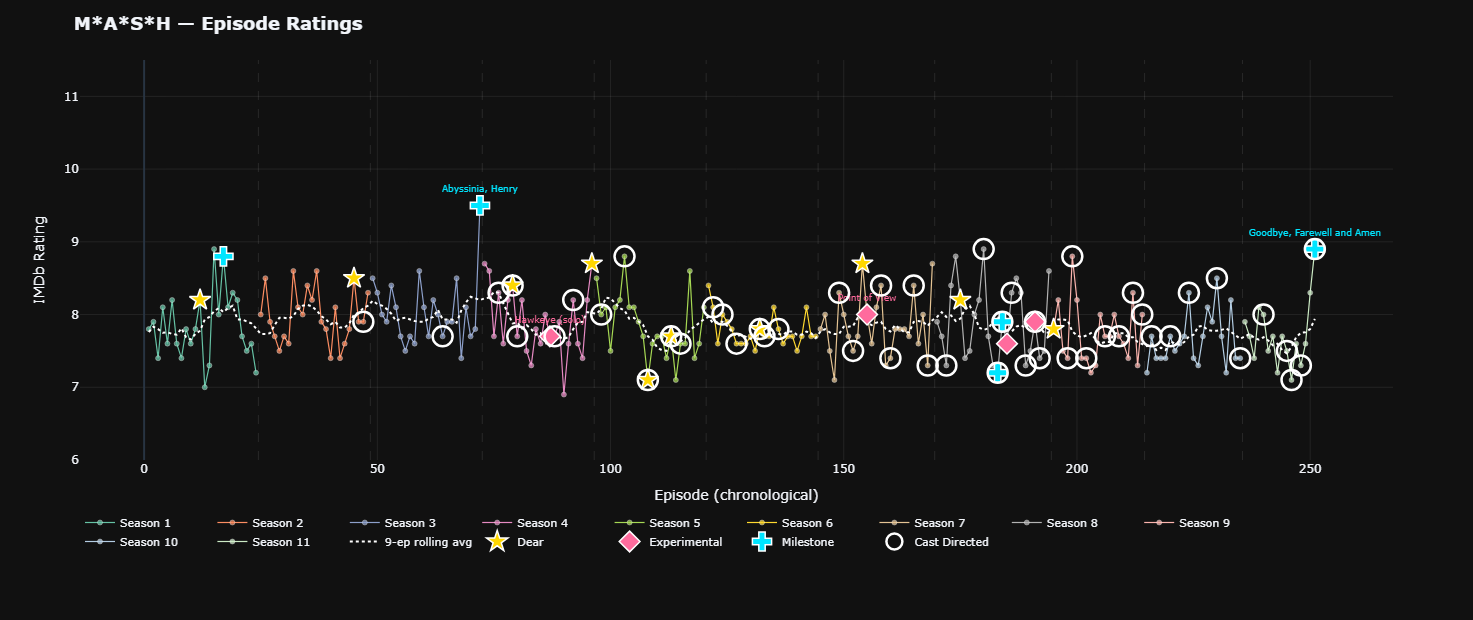

In [30]:
# ── Chart 1: Ratings Timeline — with toggleable overlays ─────────────────────
# Overlays toggled via the sticky bar in the HTML export.


seasons_sorted = sorted(df_rated['season'].unique())
N = len(seasons_sorted)
# Trace index map:
#   0 .. N-1   season scatter+line traces
#   N          rolling average
#   N+1        Dear
#   N+2        Experimental
#   N+3        Milestone
#   N+4        Cast-directed

fig1 = go.Figure()

# ── Season traces ─────────────────────────────────────────────────────────────
for i, season in enumerate(seasons_sorted):
    s   = df_rated[df_rated['season'] == season]
    col = PALETTE[i % len(PALETTE)]
    fig1.add_trace(go.Scatter(
        x=s['episode_global'], y=s['rating'],
        mode='markers+lines',
        name=f'Season {season}',
        marker=dict(size=5, color=col, opacity=0.75,
                    line=dict(width=0.5, color='white')),
        line=dict(color=col, width=1.2),
        customdata=s[['title','season','episode','year','votes']].values,
        hovertemplate=(
            '<b>%{customdata[0]}</b><br>'
            'S%{customdata[1]:02d}E%{customdata[2]:02d}<br>'
            'Rating: <b>%{y:.1f}</b>/10<br>'
            'Votes: %{customdata[4]:,.0f}<extra></extra>'
        ),
        legendgroup='seasons',
    ))

# ── Rolling average ───────────────────────────────────────────────────────────
roll = (df_rated.set_index('episode_global')['rating']
        .rolling(9, center=True, min_periods=3).mean())
fig1.add_trace(go.Scatter(
    x=roll.index, y=roll.values,
    mode='lines', name='9-ep rolling avg',
    line=dict(color='white', width=2, dash='dot'),
    hoverinfo='skip',
))

# ── Special overlays (always add all 3 categories to keep indices stable) ─────
for cat in ['Dear', 'Experimental', 'Milestone']:
    sub = df_special[df_special['special_category'] == cat].copy()
    if not sub.empty:
        sub['ann'] = sub['special_label'].apply(
            lambda x: x if x in FAMOUS_LABELS else '')
    fig1.add_trace(go.Scatter(
        x=sub['episode_global'].tolist() if not sub.empty else [],
        y=sub['rating'].tolist()          if not sub.empty else [],
        mode='markers+text',
        name=cat,
        marker=dict(
            symbol=SPECIAL_SYMBOLS[cat], size=16,
            color=SPECIAL_COLOURS[cat],
            line=dict(width=1.5, color='white')
        ),
        text=sub['ann'].tolist() if not sub.empty else [],
        textposition='top center',
        textfont=dict(size=9, color=SPECIAL_COLOURS[cat]),
        customdata=(sub[['special_label','season','episode','year','votes']].values
                    if not sub.empty else []),
        hovertemplate=(
            '<b>%{customdata[0]}</b><br>'
            'S%{customdata[1]:02d}E%{customdata[2]:02d}<br>'
            'Rating: <b>%{y:.1f}</b>/10<br>'
            'Votes: %{customdata[4]:,.0f}<extra></extra>'
        ),
    ))

# ── Cast-directed overlay ─────────────────────────────────────────────────────
fig1.add_trace(go.Scatter(
    x=df_cast['episode_global'].tolist() if len(df_cast) else [],
    y=df_cast['rating'].tolist()          if len(df_cast) else [],
    mode='markers',
    name='Cast Directed',
    marker=dict(symbol='circle-open', size=20, color='white',
                line=dict(width=2.5, color='white')),
    customdata=(df_cast[['title','season','episode','directors','votes']].values
                if len(df_cast) else []),
    hovertemplate=(
        '<b>%{customdata[0]}</b><br>'
        'S%{customdata[1]:02d}E%{customdata[2]:02d}<br>'
        'Dir: <b>%{customdata[3]}</b><br>'
        'Rating: <b>%{y:.1f}</b>/10<extra></extra>'
    ),
))

# ── Season dividers ───────────────────────────────────────────────────────────
for season in seasons_sorted[1:]:
    x0 = df_rated[df_rated['season'] == season]['episode_global'].min() - 0.5
    fig1.add_vline(x=x0,
        line=dict(color='rgba(255,255,255,0.1)', dash='dash', width=1))

# ── Layout ────────────────────────────────────────────────────────────────────
fig1.update_layout(
    title=dict(text='<b>M*A*S*H \u2014 Episode Ratings</b>', font_size=18),
    xaxis_title='Episode (chronological)', yaxis_title='IMDb Rating',
    template='plotly_dark',
    legend=dict(
        orientation='h',
        x=0, y=-0.12,
        traceorder='normal',
        font=dict(size=11),
    ),
    height=620, hovermode='closest',
    yaxis=dict(range=[6, 11.5], gridcolor='rgba(255,255,255,0.08)'),
    xaxis=dict(gridcolor='rgba(255,255,255,0.08)'),
    margin=dict(t=60, b=160),
)
fig1.show()

## 📦 Chart 2 — Season Box Plots

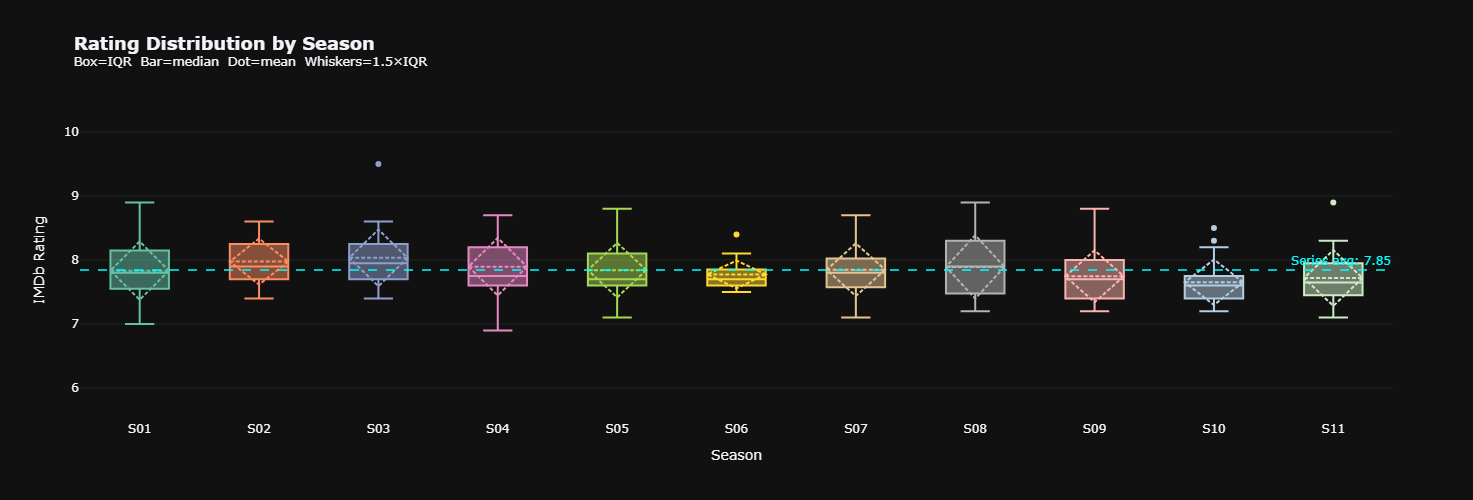

In [31]:
# ── Chart 2: Season Box Plots ────────────────────────────────────────────────
fig2 = go.Figure()
for i, season in enumerate(sorted(df_rated['season'].unique())):
    s   = df_rated[df_rated['season'] == season]
    col = PALETTE[i % len(PALETTE)]
    fig2.add_trace(go.Box(
        y=s['rating'], name=f'S{season:02d}',
        marker_color=col, boxmean='sd',
        customdata=s[['title','rating','ep_code']].values,
        hovertemplate='<b>%{customdata[0]}</b><br>%{customdata[2]}: %{customdata[1]:.1f}<extra></extra>'
    ))
fig2.add_hline(y=df_rated['rating'].mean(),
    line=dict(color='cyan', dash='dash', width=1.5),
    annotation_text=f'Series avg: {df_rated["rating"].mean():.2f}',
    annotation_font_color='cyan')
fig2.update_layout(
    title=dict(text='<b>Rating Distribution by Season</b><br>'
               '<sup>Box=IQR  Bar=median  Dot=mean  Whiskers=1.5\u00d7IQR</sup>',
               font_size=18),
    xaxis_title='Season', yaxis_title='IMDb Rating',
    template='plotly_dark', height=500, showlegend=False,
    yaxis=dict(range=[5.5, 10.5], gridcolor='rgba(255,255,255,0.08)')
)
fig2.show()


## 🥇 Chart 3 — Top 15 & Bottom 10

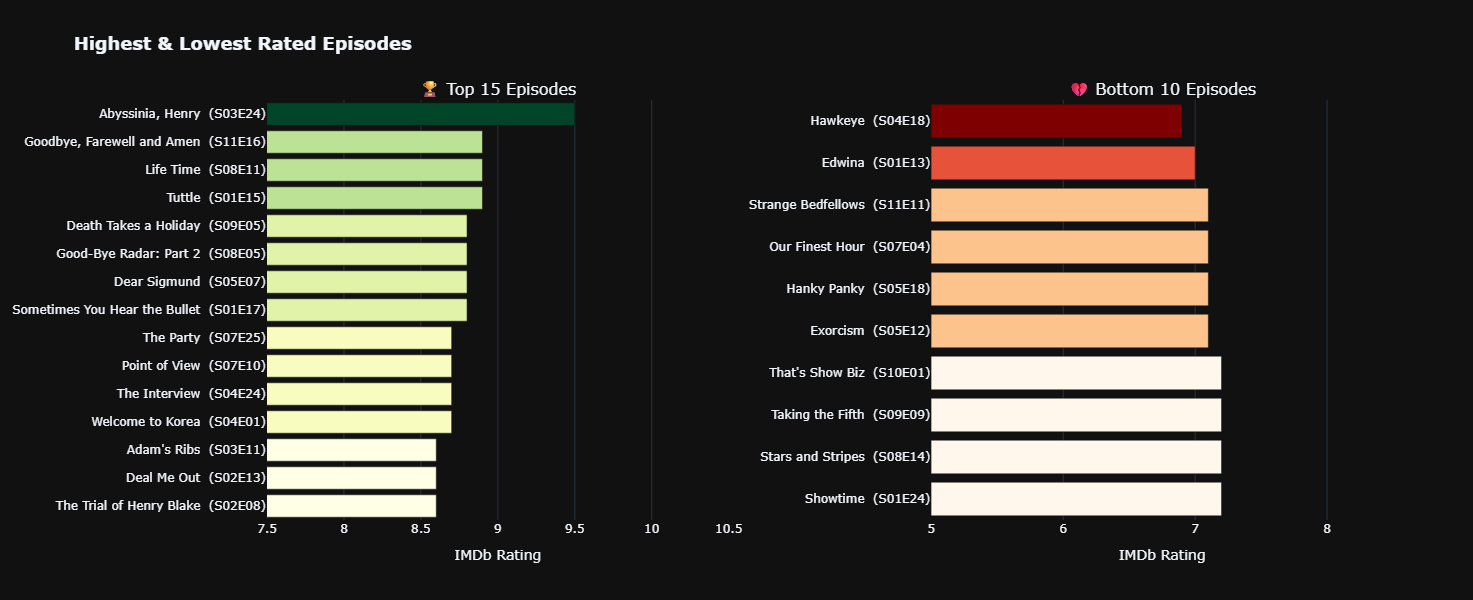

In [32]:
# ── Chart 3: Top 15 & Bottom 10 Episodes ─────────────────────────────────────
top = df_rated.nlargest(15, 'rating').sort_values('rating')
bot = df_rated.nsmallest(10, 'rating').sort_values('rating', ascending=False)
fig3 = make_subplots(rows=1, cols=2,
    subplot_titles=['\U0001f3c6 Top 15 Episodes', '\U0001f494 Bottom 10 Episodes'],
    horizontal_spacing=0.18)
fig3.add_trace(go.Bar(
    y=top['title'] + '  (' + top['ep_code'] + ')',
    x=top['rating'], orientation='h',
    marker=dict(color=top['rating'], colorscale='YlGn', showscale=False),
    customdata=top['votes'].values,
    hovertemplate='Rating: <b>%{x:.1f}</b>  |  Votes: %{customdata:,.0f}<extra></extra>'
), row=1, col=1)
fig3.add_trace(go.Bar(
    y=bot['title'] + '  (' + bot['ep_code'] + ')',
    x=bot['rating'], orientation='h',
    marker=dict(color=bot['rating'], colorscale='OrRd_r', showscale=False),
    customdata=bot['votes'].values,
    hovertemplate='Rating: <b>%{x:.1f}</b>  |  Votes: %{customdata:,.0f}<extra></extra>'
), row=1, col=2)
fig3.update_xaxes(range=[7.5, 10.5], title_text='IMDb Rating', row=1, col=1)
fig3.update_xaxes(range=[5.0, 8.5],  title_text='IMDb Rating', row=1, col=2)
fig3.update_layout(title=dict(text='<b>Highest & Lowest Rated Episodes</b>', font_size=18),
    template='plotly_dark', height=600, showlegend=False)
fig3.show()


## 🔥 Chart 4 — Rating Heatmap

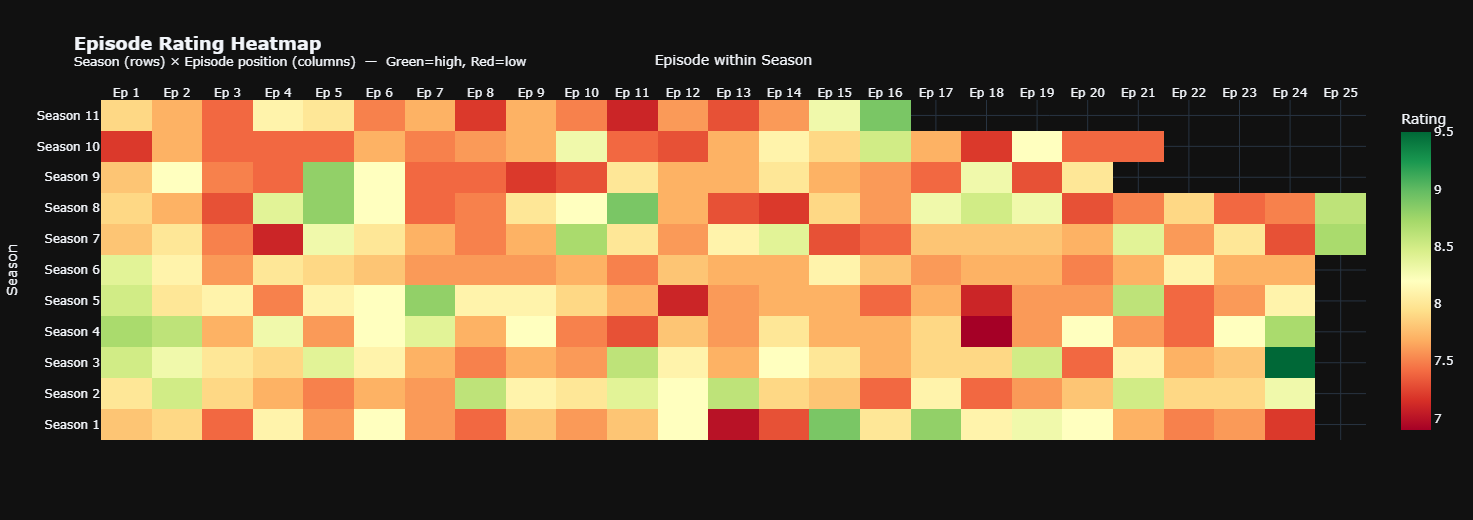

In [33]:
# ── Chart 4: Rating Heatmap ───────────────────────────────────────────────────
pivot       = df_rated.pivot_table(index='season', columns='episode', values='rating')
title_pivot = df_rated.pivot_table(index='season', columns='episode',
                                    values='title', aggfunc='first')
hover_text = []
for s in pivot.index:
    row = []
    for e in pivot.columns:
        try:
            rv = pivot.loc[s, e];  tv = title_pivot.loc[s, e]
            row.append(f'S{s:02d}E{e:02d}: {tv}<br>Rating: {rv:.1f}' if pd.notna(rv) else '')
        except Exception:
            row.append('')
    hover_text.append(row)
fig4 = go.Figure(go.Heatmap(
    z=pivot.values,
    x=[f'Ep {c}' for c in pivot.columns],
    y=[f'Season {r}' for r in pivot.index],
    text=hover_text, hovertemplate='%{text}<extra></extra>',
    colorscale='RdYlGn', zmid=8.2,
    colorbar=dict(title='Rating')
))
fig4.update_layout(
    title=dict(text='<b>Episode Rating Heatmap</b><br>'
               '<sup>Season (rows) \u00d7 Episode position (columns)  \u2014  Green=high, Red=low</sup>',
               font_size=18),
    xaxis=dict(title='Episode within Season', side='top'),
    yaxis_title='Season', template='plotly_dark', height=520)
fig4.show()


## 💬 Chart 5 — Audience Engagement

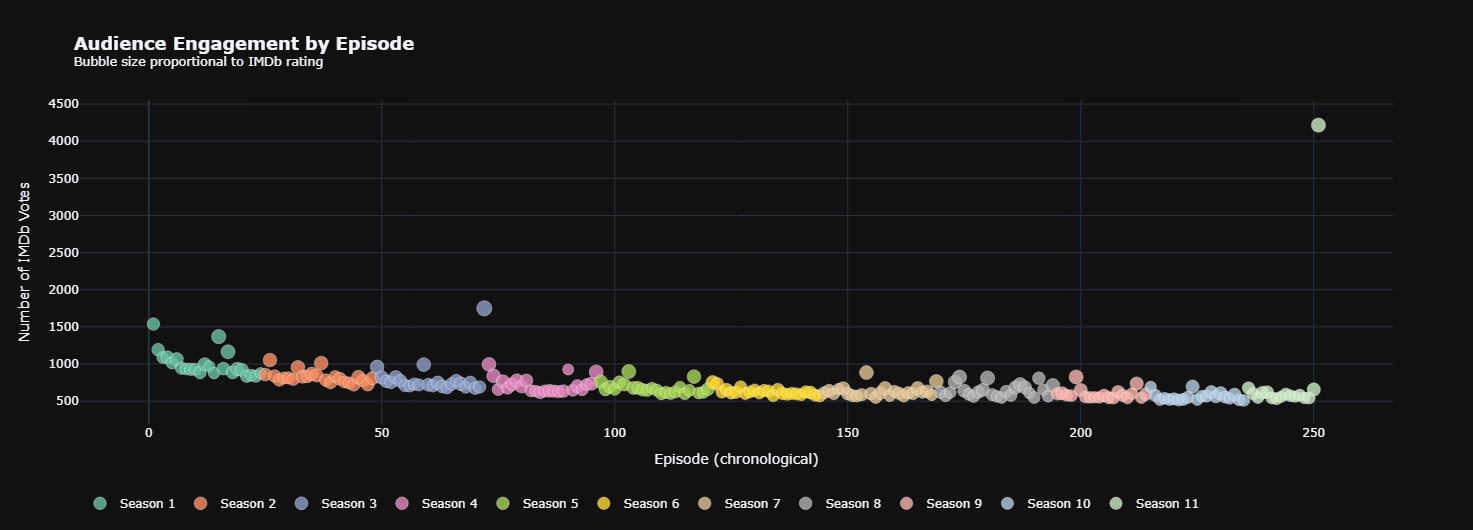

In [34]:
# ── Chart 5: Audience Engagement (Vote Counts) ───────────────────────────────
df_v = df_rated.dropna(subset=['votes']).copy()
fig5 = go.Figure()
for i, season in enumerate(sorted(df_v['season'].unique())):
    s = df_v[df_v['season'] == season]
    col = PALETTE[i % len(PALETTE)]
    fig5.add_trace(go.Scatter(
        x=s['episode_global'], y=s['votes'],
        mode='markers', name=f'Season {season}',
        marker=dict(size=s['rating'] * 1.6, color=col, opacity=0.8,
                    line=dict(width=0.5, color='white')),
        customdata=s[['title','ep_code','rating']].values,
        hovertemplate=(
            '<b>%{customdata[0]}</b> (%{customdata[1]})<br>'
            'Votes: <b>%{y:,.0f}</b><br>'
            'Rating: %{customdata[2]:.1f}/10<extra></extra>'
        )
    ))
fig5.update_layout(
    title=dict(text='<b>Audience Engagement by Episode</b><br>'
               '<sup>Bubble size proportional to IMDb rating</sup>', font_size=18),
    xaxis_title='Episode (chronological)', yaxis_title='Number of IMDb Votes',
    template='plotly_dark', legend=dict(orientation='h', y=-0.2),
    height=530, hovermode='closest')
fig5.show()


## 📊 Chart 6 — Season Averages

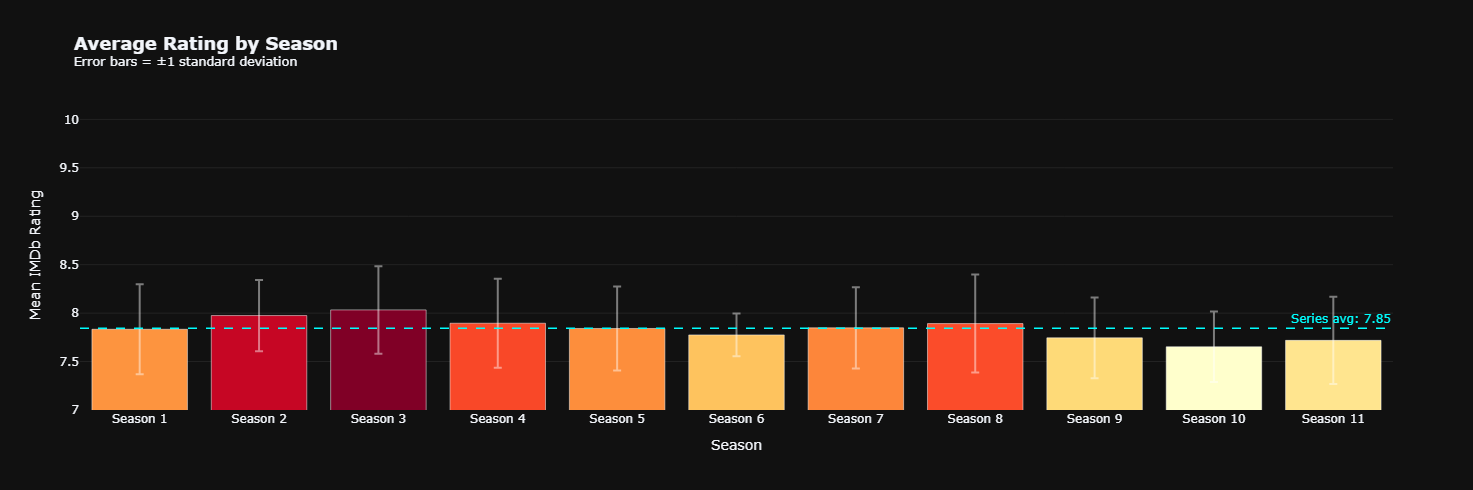


Season stats:
season_label  mean_rating  std_rating  episode_count  min_rating  max_rating
    Season 1     7.833333    0.465007             24         7.0         8.9
    Season 2     7.975000    0.367423             24         7.4         8.6
    Season 3     8.033333    0.451728             24         7.4         9.5
    Season 4     7.895833    0.459186             24         6.9         8.7
    Season 5     7.841667    0.434308             24         7.1         8.8
    Season 6     7.775000    0.221163             24         7.5         8.4
    Season 7     7.848000    0.419444             25         7.1         8.7
    Season 8     7.892000    0.505734             25         7.2         8.9
    Season 9     7.745000    0.416091             20         7.2         8.8
   Season 10     7.652381    0.364169             21         7.2         8.5
   Season 11     7.718750    0.450509             16         7.1         8.9


In [35]:
# ── Chart 6: Season Average Ratings ─────────────────────────────────────────
season_stats = df_rated.groupby('season').agg(
    mean_rating  =('rating','mean'),
    std_rating   =('rating','std'),
    min_rating   =('rating','min'),
    max_rating   =('rating','max'),
    episode_count=('rating','count'),
    total_votes  =('votes','sum')
).reset_index()
season_stats['season_label'] = 'Season ' + season_stats['season'].astype(str)
fig6 = go.Figure(go.Bar(
    x=season_stats['season_label'], y=season_stats['mean_rating'],
    error_y=dict(type='data', array=season_stats['std_rating'],
                 visible=True, color='rgba(255,255,255,0.45)'),
    marker=dict(color=season_stats['mean_rating'], colorscale='YlOrRd',
                line=dict(color='white', width=0.5)),
    customdata=season_stats[['episode_count','min_rating','max_rating','total_votes']].values,
    hovertemplate=(
        '<b>%{x}</b><br>Mean: <b>%{y:.2f}</b><br>'
        'Episodes: %{customdata[0]}<br>'
        'Range: %{customdata[1]:.1f}\u2013%{customdata[2]:.1f}<br>'
        'Total votes: %{customdata[3]:,.0f}<extra></extra>'
    )
))
fig6.add_hline(y=df_rated['rating'].mean(),
    line=dict(color='cyan', dash='dash', width=1.5),
    annotation_text=f'Series avg: {df_rated["rating"].mean():.2f}',
    annotation_font_color='cyan', annotation_position='top right')
fig6.update_layout(
    title=dict(text='<b>Average Rating by Season</b><br>'
               '<sup>Error bars = \u00b11 standard deviation</sup>', font_size=18),
    xaxis_title='Season', yaxis_title='Mean IMDb Rating',
    template='plotly_dark', height=490, showlegend=False,
    yaxis=dict(range=[7, 10.2], gridcolor='rgba(255,255,255,0.08)'))
fig6.show()
print("\nSeason stats:")
print(season_stats[['season_label','mean_rating','std_rating',
                     'episode_count','min_rating','max_rating']].to_string(index=False))


## 🎬 Chart 7 — Director Leaderboard
Gold bars = cast members. Blue = professional directors.

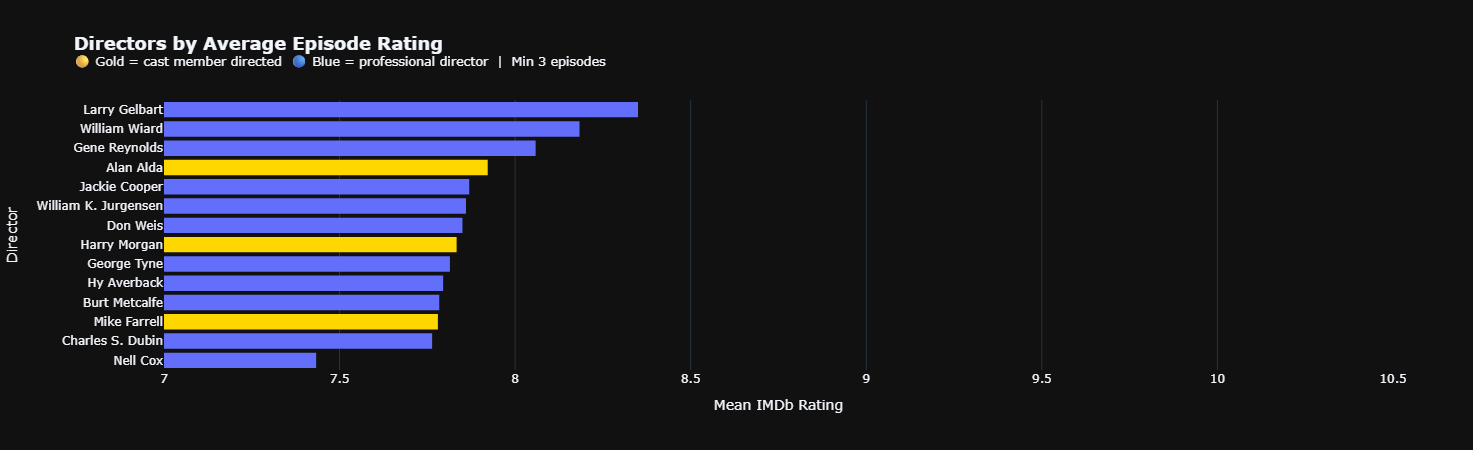

In [36]:
# ── Chart 7: Director Leaderboard (all directors, min 3 episodes) ────────────
if df_rated['directors'].notna().sum() > 0:
    dir_df  = df_rated[df_rated['directors'].notna()].copy()
    dir_exp = (dir_df.assign(director=dir_df['directors'].str.split(', '))
               .explode('director'))
    dir_stats = (dir_exp.groupby('director')
                 .agg(episodes=('title','count'),
                      mean_rating=('rating','mean'),
                      min_rating =('rating','min'),
                      max_rating =('rating','max'))
                 .reset_index()
                 .query('episodes >= 3')
                 .sort_values('mean_rating'))
    dir_stats['is_cast'] = dir_stats['director'].isin(
        ['Alan Alda','Mike Farrell','Harry Morgan','Jamie Farr',
         'William Christopher','David Ogden Stiers','Loretta Swit',
         'Gary Burghoff','Wayne Rogers','McLean Stevenson'])
    colours = dir_stats['is_cast'].map({True: '#FFD700', False: '#636efa'})
    fig7 = go.Figure(go.Bar(
        x=dir_stats['mean_rating'],
        y=dir_stats['director'],
        orientation='h',
        marker=dict(color=colours, line=dict(width=0)),
        customdata=dir_stats[['episodes','min_rating','max_rating','is_cast']].values,
        hovertemplate=(
            '<b>%{y}</b>%{customdata[3]}<br>'
            'Mean: <b>%{x:.2f}</b>  |  Episodes: %{customdata[0]}<br>'
            'Range: %{customdata[1]:.1f}\u2013%{customdata[2]:.1f}<extra></extra>'
        )
    ))
    fig7.update_layout(
        title=dict(
            text='<b>Directors by Average Episode Rating</b><br>'
                 '<sup>\U0001f7e1 Gold = cast member directed  \U0001f535 Blue = professional director  |  Min 3 episodes</sup>',
            font_size=18),
        xaxis=dict(title='Mean IMDb Rating', range=[7, 10.5]),
        yaxis_title='Director', template='plotly_dark',
        height=max(450, len(dir_stats) * 24), showlegend=False
    )
    fig7.show()
else:
    print("\u26a0  No director data \u2014 delete mash_episodes.csv and re-run Cell 3")
    fig7 = None


## ⭐ Chart 8 — Special Episodes vs Regular

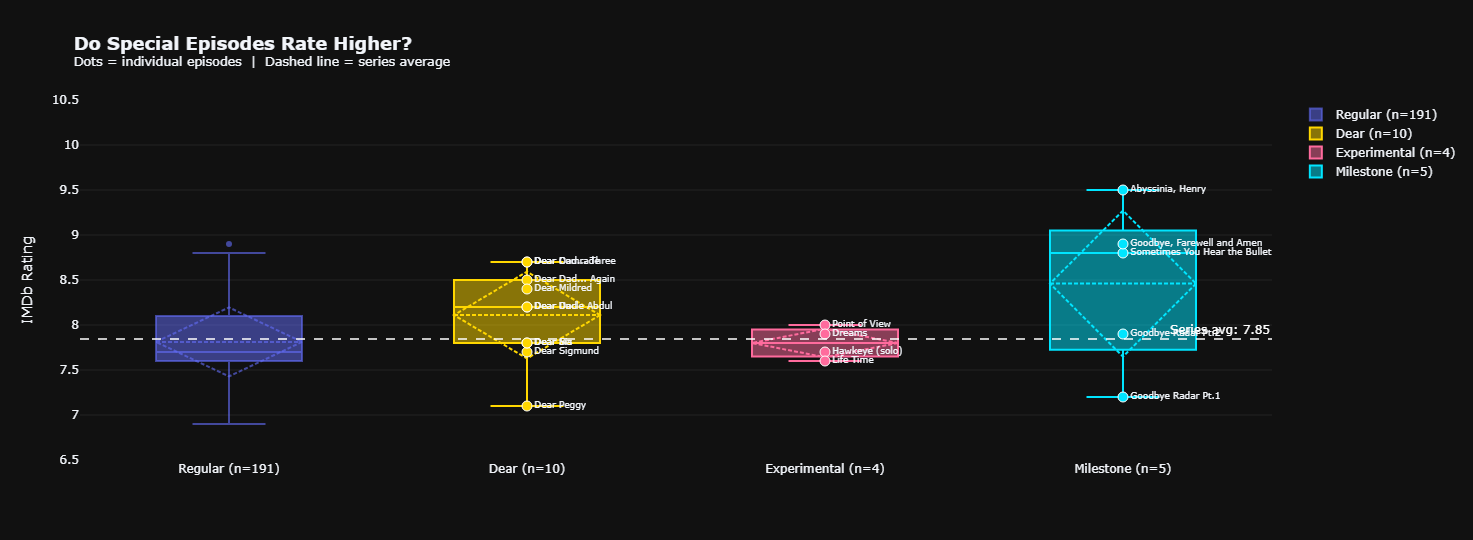

In [37]:
# ── Chart 8: Do Special Episodes Rate Higher? ────────────────────────────────
fig8 = go.Figure()
for cat, colour, label in [
    ('Regular',      'rgba(100,110,250,0.6)', f'Regular (n={len(df_regular)})'),
    ('Dear',         '#FFD700', f'Dear (n={len(df_special[df_special["special_category"]=="Dear"])})'),
    ('Experimental', '#FF6B9D', f'Experimental (n={len(df_special[df_special["special_category"]=="Experimental"])})'),
    ('Milestone',    '#00E5FF', f'Milestone (n={len(df_special[df_special["special_category"]=="Milestone"])})'),
]:
    data = df_regular['rating'] if cat == 'Regular' else df_special[df_special['special_category'] == cat]['rating']
    fig8.add_trace(go.Box(
        y=data, name=label,
        marker_color=colour, boxmean='sd',
    ))

# Individual special episode dots
for cat, colour in [('Dear','#FFD700'),('Experimental','#FF6B9D'),('Milestone','#00E5FF')]:
    sub  = df_special[df_special['special_category'] == cat]
    lbl  = f'Dear (n={len(df_special[df_special["special_category"]=="Dear"])})' if cat == 'Dear' else            f'Experimental (n={len(df_special[df_special["special_category"]=="Experimental"])})' if cat == 'Experimental' else            f'Milestone (n={len(df_special[df_special["special_category"]=="Milestone"])})'
    fig8.add_trace(go.Scatter(
        x=[lbl] * len(sub), y=sub['rating'],
        mode='markers+text',
        marker=dict(size=10, color=colour, line=dict(width=1, color='white')),
        text=sub['special_label'], textposition='middle right',
        textfont=dict(size=9), showlegend=False,
        hovertemplate='<b>%{text}</b><br>Rating: %{y:.1f}<extra></extra>'
    ))

fig8.add_hline(y=df_rated['rating'].mean(),
    line=dict(color='white', dash='dash', width=1.5),
    annotation_text=f'Series avg: {df_rated["rating"].mean():.2f}',
    annotation_font_color='white')
fig8.update_layout(
    title=dict(text='<b>Do Special Episodes Rate Higher?</b><br>'
               '<sup>Dots = individual episodes  |  Dashed line = series average</sup>',
               font_size=18),
    yaxis=dict(title='IMDb Rating', range=[6.5, 10.5],
               gridcolor='rgba(255,255,255,0.08)'),
    template='plotly_dark', height=540, showlegend=True,
)
fig8.show()


## 🎭 Chart 9 — Cast-Directed Analysis

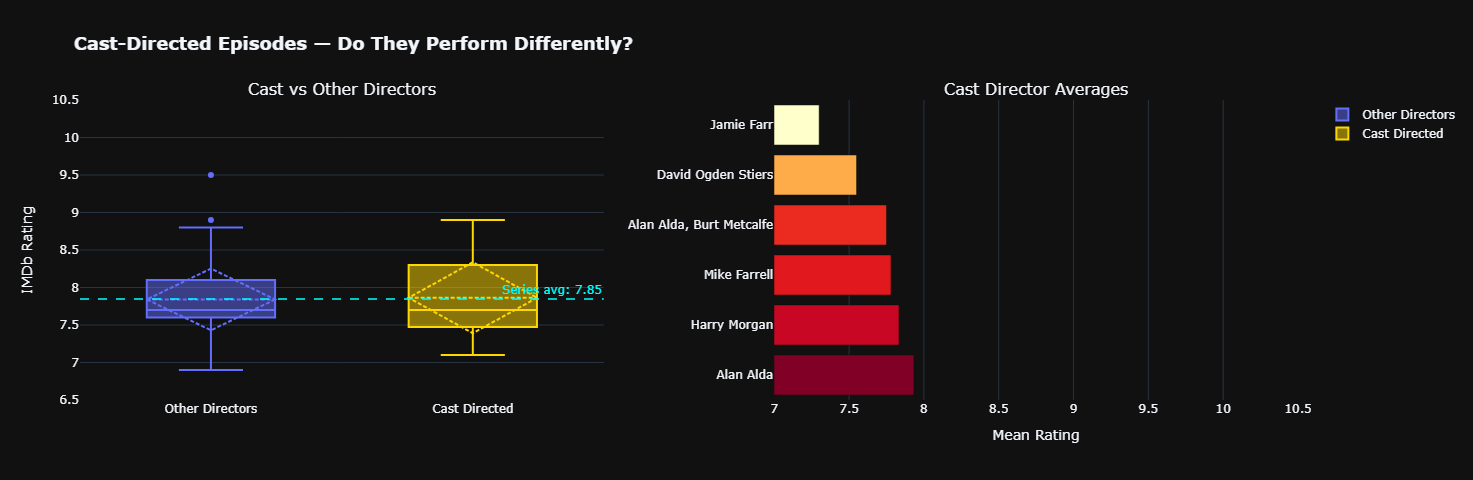

In [38]:
# ── Chart 9: Cast-Directed Episodes Analysis ─────────────────────────────────
if len(df_cast) > 0:
    cast_stats = (df_cast.groupby('directors')
                  .agg(episodes=('title','count'),
                       mean_rating=('rating','mean'),
                       min_rating =('rating','min'),
                       max_rating =('rating','max'))
                  .reset_index()
                  .sort_values('mean_rating', ascending=False))

    fig9 = make_subplots(rows=1, cols=2,
        subplot_titles=['Cast vs Other Directors', 'Cast Director Averages'],
        horizontal_spacing=0.14)

    non_cast = df_rated[~df_rated['is_cast_directed']]
    for data, name, colour in [
        (non_cast['rating'],  'Other Directors', '#636efa'),
        (df_cast['rating'],   'Cast Directed',   '#FFD700'),
    ]:
        fig9.add_trace(go.Box(y=data, name=name,
                              marker_color=colour, boxmean='sd'), row=1, col=1)

    fig9.add_trace(go.Bar(
        x=cast_stats['mean_rating'], y=cast_stats['directors'],
        orientation='h',
        showlegend=False,
        marker=dict(color=cast_stats['mean_rating'], colorscale='YlOrRd', showscale=False),
        customdata=cast_stats[['episodes','min_rating','max_rating']].values,
        hovertemplate=(
            '<b>%{y}</b><br>'
            'Mean: <b>%{x:.2f}</b>  |  Episodes: %{customdata[0]}<br>'
            'Range: %{customdata[1]:.1f}\u2013%{customdata[2]:.1f}<extra></extra>'
        )
    ), row=1, col=2)

    fig9.add_hline(y=df_rated['rating'].mean(), row=1, col=1,
        line=dict(color='cyan', dash='dash', width=1.5),
        annotation_text=f'Series avg: {df_rated["rating"].mean():.2f}',
        annotation_font_color='cyan')

    fig9.update_layout(
        title=dict(text='<b>Cast-Directed Episodes \u2014 Do They Perform Differently?</b>',
                   font_size=18),
        template='plotly_dark', height=480, showlegend=True)
    fig9.update_yaxes(title_text='IMDb Rating', range=[6.5, 10.5], row=1, col=1)
    fig9.update_xaxes(title_text='Mean Rating', range=[7, 10.5], row=1, col=2)
    fig9.show()
else:
    print("\u26a0  No cast-directed episodes identified \u2014 check directors column")
    fig9 = None


## 💾 Export — Standalone HTML Report

In [39]:
# ── Export: Standalone HTML Report with Toggle Panel ─────────────────────────
import plotly as _pm

_js_path = os.path.join(os.path.dirname(_pm.__file__), 'package_data', 'plotly.min.js')
if os.path.exists(_js_path):
    with open(_js_path, encoding='utf-8') as _f:
        _plotly_js = f'<script>{_f.read()}</script>'
else:
    _plotly_js = '<script src="https://cdn.plot.ly/plotly-latest.min.js"></script>'

# Compute trace indices (must match Chart 1 build logic)
N = len(sorted(df_rated['season'].unique()))   # number of season traces
S_IDX = f'[{N+1},{N+2},{N+3}]'                # Dear, Experimental, Milestone
C_IDX = f'[{N+4}]'                            # Cast-directed

CHART1_ID = 'mash-chart1'

overall_mean = df_rated['rating'].mean()
best  = df_rated.loc[df_rated['rating'].idxmax()]
worst = df_rated.loc[df_rated['rating'].idxmin()]

top20 = df_rated.nlargest(20,'rating')[['ep_code','title','rating','votes','year']].copy()
top20['rating'] = top20['rating'].map('{:.1f}'.format)
top20['votes']  = top20['votes'].apply(lambda x: f'{int(x):,}' if pd.notna(x) else '—')
top20.columns   = ['Code','Title','Rating','Votes','Year']

CSS = """
*{box-sizing:border-box;margin:0;padding:0}
body{background:#0d1117;color:#e6edf3;font-family:'Segoe UI',system-ui,sans-serif;
     padding:24px 20px;padding-top:90px}
h1{color:#58a6ff;font-size:1.9em;border-bottom:2px solid #21262d;
   padding-bottom:14px;margin-bottom:24px}
h2{color:#79c0ff;font-size:1.2em;margin:40px 0 12px}
.sticky{position:fixed;top:0;left:0;right:0;z-index:9999;
        background:#161b22;border-bottom:2px solid #30363d;
        padding:10px 20px;display:flex;align-items:center;gap:12px;flex-wrap:wrap}
.sticky-label{color:#8b949e;font-size:.82em;font-weight:600;white-space:nowrap}
.btn-group{display:flex;gap:4px}
.tbtn{padding:5px 14px;border-radius:6px;border:1px solid #444;cursor:pointer;
      font-size:.82em;font-weight:600;transition:all .15s}
.tbtn.specials{background:#332b00;color:#FFD700;border-color:#FFD700}
.tbtn.specials:hover{background:#4a3d00}
.tbtn.specials.active{background:#FFD700;color:#0d1117}
.tbtn.cast{background:#1a1a1a;color:#e6edf3;border-color:#888}
.tbtn.cast:hover{background:#2a2a2a}
.tbtn.cast.active{background:#e6edf3;color:#0d1117}
.divider{width:1px;height:28px;background:#30363d;margin:0 4px}
.grid{display:grid;grid-template-columns:repeat(auto-fill,minmax(175px,1fr));
      gap:14px;margin-bottom:32px}
.card{background:#161b22;border:1px solid #30363d;border-radius:10px;
      padding:18px;text-align:center}
.val{font-size:1.9em;font-weight:700;color:#58a6ff}
.lbl{font-size:.82em;color:#8b949e;margin-top:6px;line-height:1.35}
.chart-wrap{margin:20px 0;border:1px solid #30363d;border-radius:10px;overflow:hidden}
table{width:100%;border-collapse:collapse;font-size:.88em;margin-top:8px}
th{background:#161b22;color:#8b949e;padding:9px 14px;text-align:left;
   border-bottom:1px solid #30363d;font-weight:600}
td{padding:8px 14px;border-bottom:1px solid #21262d}
tr:hover td{background:#1c2128}
footer{margin-top:60px;padding-top:18px;border-top:1px solid #21262d;
       color:#8b949e;font-size:.78em;text-align:center}
"""

TOGGLE_JS = f"""
<script>
var _specials_on = true;
var _cast_on     = true;

function toggleSpecials() {{
    _specials_on = !_specials_on;
    var el = document.getElementById('btn-specials');
    el.classList.toggle('active', _specials_on);
    el.textContent = '✦ Specials: ' + (_specials_on ? 'ON' : 'OFF');
    var div = document.getElementById('{CHART1_ID}');
    if (div && div.data) {{
        Plotly.restyle('{CHART1_ID}', {{visible: _specials_on}}, {S_IDX});
    }}
}}
function toggleCast() {{
    _cast_on = !_cast_on;
    var el = document.getElementById('btn-cast');
    el.classList.toggle('active', _cast_on);
    el.textContent = '🎬 Cast Dir: ' + (_cast_on ? 'ON' : 'OFF');
    var div = document.getElementById('{CHART1_ID}');
    if (div && div.data) {{
        Plotly.restyle('{CHART1_ID}', {{visible: _cast_on}}, {C_IDX});
    }}
}}
// Set initial active state once page loads
window.addEventListener('load', function() {{
    document.getElementById('btn-specials').classList.add('active');
    document.getElementById('btn-cast').classList.add('active');
}});
</script>
"""

STICKY_BAR = """
<div class="sticky">
  <span class="sticky-label">Chart 1 overlays:</span>
  <div class="btn-group">
    <button id="btn-specials" class="tbtn specials" onclick="toggleSpecials()">
      ✦ Specials: ON
    </button>
  </div>
  <div class="divider"></div>
  <div class="btn-group">
    <button id="btn-cast" class="tbtn cast" onclick="toggleCast()">
      🎬 Cast Dir: ON
    </button>
  </div>
  <span class="sticky-label" style="margin-left:auto;color:#444;font-size:.75em">
    M*A*S*H — IMDb Analytics
  </span>
</div>
"""

html = (
    '<!DOCTYPE html>\n<html lang="en">\n<head>\n'
    '<meta charset="UTF-8">\n'
    '<meta name="viewport" content="width=device-width, initial-scale=1.0">\n'
    '<title>M*A*S*H — IMDb Analytics</title>\n'
    + _plotly_js + '\n'
    + f'<style>{CSS}</style>\n'
    + TOGGLE_JS
    + '</head>\n<body>\n'
    + STICKY_BAR
    + '<h1>📺 M*A*S*H — IMDb Episode Analytics</h1>\n'
    + f'''<div class="grid">
  <div class="card"><div class="val">{len(df)}</div><div class="lbl">Episodes</div></div>
  <div class="card"><div class="val">{df['season'].nunique()}</div><div class="lbl">Seasons</div></div>
  <div class="card"><div class="val">{overall_mean:.2f}</div><div class="lbl">Mean Rating</div></div>
  <div class="card"><div class="val">{best['rating']:.1f}</div>
    <div class="lbl">Highest Rated<br><small>{best['title']}</small></div></div>
  <div class="card"><div class="val">{worst['rating']:.1f}</div>
    <div class="lbl">Lowest Rated<br><small>{worst['title']}</small></div></div>
</div>\n'''
)

# Chart 1 gets a named div_id so the JS can target it
import copy
fig1_clean = copy.deepcopy(fig1)
fig1_clean.update_layout(updatemenus=[])
all_figs = [fig1_clean, fig2, fig3, fig4, fig5, fig6]
for _f in [fig7, fig8, fig9]:
    try:
        if _f is not None: all_figs.append(_f)
    except NameError:
        pass

for i, fig in enumerate(all_figs):
    div_id = CHART1_ID if i == 0 else f'mash-chart{i+1}'
    html += (f'<div class="chart-wrap">'
             f'{to_html(fig, full_html=False, include_plotlyjs=False, div_id=div_id)}'
             f'</div>\n')

html += (
    '<h2>🏆 Top 20 Episodes</h2>'
    + top20.to_html(index=False, border=0, classes='')
    + '\n<footer>Generated with Python · IMDb Datasets · Plotly</footer>'
    '\n</body>\n</html>'
)

report_path = 'mash_analytics.html'
with open(report_path, 'w', encoding='utf-8') as fh:
    fh.write(html)

size_mb = os.path.getsize(report_path) / (1024*1024)
print(f'✓ Saved → {report_path}  ({size_mb:.1f} MB)')

✓ Saved → mash_analytics.html  (4.7 MB)
